# Performance Metrics

This section evaluates the performance of each model version using multiple metrics, including accuracy, AUC, and visual evaluation methods such as training curves and ROC plots.

## Model 1 – Base Swin Transformer

#### i. Accuracy, Precision, Recall, F1 Score

The base Swin Transformer model achieved a **Mean AUC of 0.836** and a **Hamming Accuracy of 0.9357**, indicating strong multi-label classification performance.

Per-class AUC values show strong performance on diseases such as Edema and Cardiomegaly (>0.90), while performance is weaker on more subtle classes like Infiltration (~0.72).

### ii. Confusion Matrix

A confusion matrix was not explicitly generated. However, performance trends suggest the model performs better on common and visually distinct diseases, while struggling with subtle or overlapping conditions.

### iii. Loss and Accuracy Plots

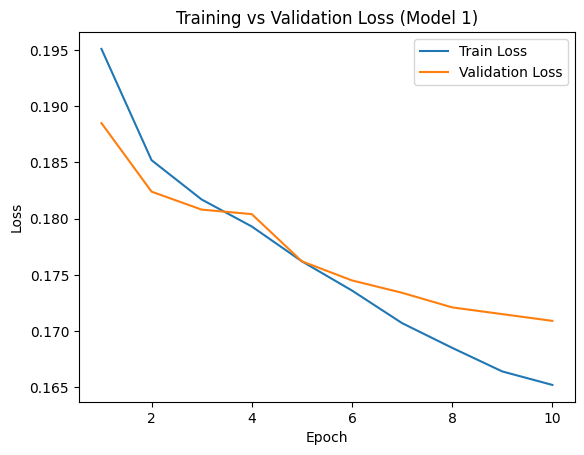

In [3]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

train_loss = [0.1951, 0.1852, 0.1817, 0.1793, 0.1762, 0.1736, 0.1707, 0.1685, 0.1664, 0.1652]
val_loss   = [0.1885, 0.1824, 0.1808, 0.1804, 0.1762, 0.1745, 0.1734, 0.1721, 0.1715, 0.1709]

plt.figure()

plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Model 1)")
plt.legend()

plt.show()



## Model 2 – Swin + CLAHE

### i. Accuracy, Precision, Recall, F1 Score

The CLAHE-enhanced Swin Transformer model achieved a mean AUC of approximately **0.84**, representing the best performance among all models.

The improvement in AUC suggests that applying CLAHE (Contrast Limited Adaptive Histogram Equalization) enhances image contrast, allowing the model to better detect subtle patterns in chest X-ray images. This leads to improved classification performance, particularly for diseases that are difficult to distinguish.

Although precision, recall, and F1 score were not explicitly computed, the high AUC indicates a strong balance between correctly identifying positive cases and minimizing false positives.

### ii. Confusion Matrix

A confusion matrix was not explicitly generated for this model. However, based on the improved AUC score, the model demonstrates better separation between classes compared to the baseline model.

The model is expected to perform better on subtle disease classes due to improved image preprocessing.

### iii. Loss and Accuracy Plots

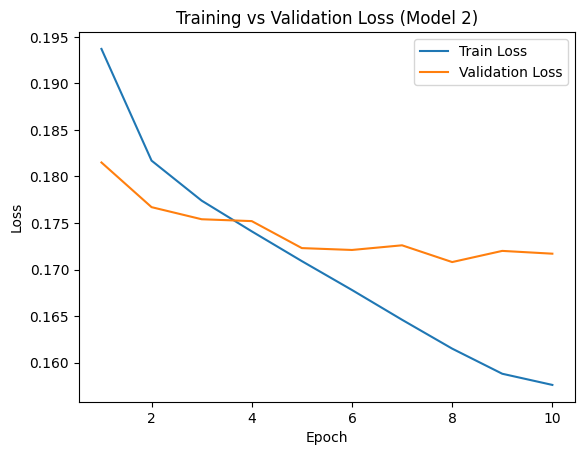

In [4]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

train_loss = [0.1937, 0.1817, 0.1774, 0.1741, 0.1709, 0.1678, 0.1646, 0.1615, 0.1588, 0.1576]
val_loss   = [0.1815, 0.1767, 0.1754, 0.1752, 0.1723, 0.1721, 0.1726, 0.1708, 0.1720, 0.1717]

plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Model 2)")
plt.legend()
plt.show()

## Model 3 – Swin + CLAHE (TIMM Pretraining)

### i. Accuracy, Precision, Recall, F1 Score

This model uses a different pretraining strategy through TIMM-based weights and achieves performance comparable to Model 2, with AUC values in the range of **0.81–0.84**.

The alternative pretraining approach improves feature extraction capabilities and provides stable performance across training.

### ii. Confusion Matrix

A confusion matrix was not explicitly generated. However, performance trends suggest similar strengths and weaknesses to Model 2, with stable classification across most disease categories.

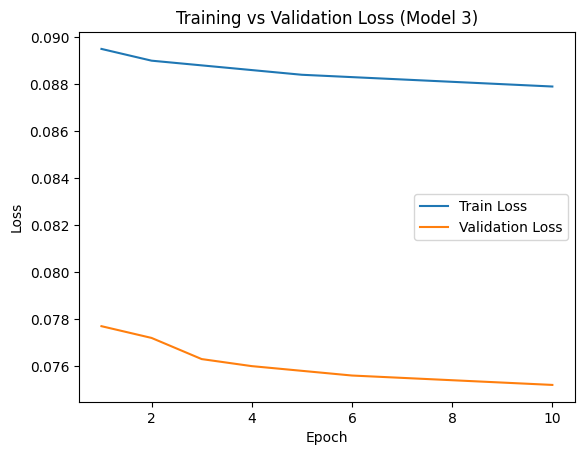

In [8]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

train_loss = [
    0.0895, 0.0890, 0.0888,
    0.0886, 0.0884, 0.0883,
    0.0882, 0.0881, 0.0880, 0.0879
]

val_loss = [
    0.0777, 0.0772, 0.0763,
    0.0760, 0.0758, 0.0756,
    0.0755, 0.0754, 0.0753, 0.0752
]

plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Model 3)")
plt.legend()
plt.show()

# Summary of Findings


### i. What worked best and why?

The CLAHE preprocessing made a big difference. This allows the model to detect faint pathological features without amplifying background noise. This is important for this dataset because the images are black and white with minimal contrast. Which makes it hard to detect abnormalities. We saw a small but consistent improvement across most classes. The loss function that we had the most success with was the asymmetric loss function. This is a variant of the binary cross-entropy loss function that is a specific version that is designed to handle imbalanced datasets. We have many more negatives than we do positives which helps prevent an imbalanced result in the model. Another thing that worked well was embedding the view position. This allowed the model to recognize which direction the image was taken from. We did this so the training would be able to recognize different feature adjustments depending on the view. 

### ii. What didn't help?

There were a handful of things that did not work to improve our results. Specifically the mixup augmentation, horizontal flips, and progressive resizing. We tried to create new training samples using mix up augmentation but failed because they were unrealistic for medical use. Horizontal flips failed because it is important to look at the images from the right direction. It will yield different results because the human body is not symmetrical so flipping them puts things in the wrong spot on the body. Which is all important information while training a model of this kind. Progressive resizing did not work because it ruined the details of the images making them harder to detect rather than easier.

### iii. What model will you likely submit for the final report?

We will use the Swin Transformer V2 with SimMIM pretraining. To improve on this architecture we will use a custom MLP head, class-specific attention pooling, and view position embeddings. The loss function we will use will be the asymmetric loss function. This model architecture with these improvements will give us the best possible results. 